In [ ]:
!pip install hmmlearn

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [ ]:
# Load the dataset
df = pd.read_csv('dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (265978, 21)


,Unnamed: 0,Time,Record Type,Glucose,Scan Glucose (mmol/L),Rapid Insulin,Carbohydrates,Long Insulin,Strip Glucose (mmol/L),Previous Time,...,Date,Tags,Insulin (Meal),Insulin (Correction),GI,Body weight (kg),Food type,bpm,distance,calories
0,0,2020-11-02 18:09:00,0.0,7.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2020-11-02 18:24:00,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2020-11-02 18:38:00,0.0,7.6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2020-11-02 18:53:00,0.0,7.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2020-11-02 19:08:00,0.0,7.3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,2020-11-02 19:24:00,0.0,7.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,2020-11-02 19:39:00,0.0,7.7,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,2020-11-02 19:54:00,0.0,8.1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,2020-11-02 20:08:00,0.0,8.6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,2020-11-02 20:23:00,0.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
## Data Exploration & Preprocessing

In [ ]:
# Basic info
print(f"Total records: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Total records: 265978

Columns: ['Unnamed: 0', 'Time', 'Record Type', 'Glucose', 'Scan Glucose (mmol/L)', 'Rapid Insulin', 'Carbohydrates', 'Long Insulin', 'Strip Glucose (mmol/L)', 'Previous Time', 'Updated Time', 'Date', 'Tags', 'Insulin (Meal)', 'Insulin (Correction)', 'GI', 'Body weight (kg)', 'Food type', 'bpm', 'distance', 'calories']

Data types:
Unnamed: 0                  int64
Time                       object
Record Type               float64
Glucose                   float64
Scan Glucose (mmol/L)     float64
Rapid Insulin             float64
Carbohydrates             float64
Long Insulin              float64
Strip Glucose (mmol/L)    float64
Previous Time              object
Updated Time               object
Date                       object
Tags                       object
Insulin (Meal)            float64
Insulin (Correction)      float64
GI                         object
Body weight (kg)          float64
Food type                  object
bpm                       float6

In [ ]:
# Statistical summary
df.describe()

,Unnamed: 0,Record Type,Glucose,Scan Glucose (mmol/L),Rapid Insulin,Carbohydrates,Long Insulin,Strip Glucose (mmol/L),Insulin (Meal),Insulin (Correction),Body weight (kg),bpm,distance,calories
count,265978.000000,49804.000000,38337.000000,10405.000000,1051.000000,1605.000000,184.000000,51.000000,280.000000,257.000000,40.000000,205117.000000,214387.000000,214387.000000
mean,132988.500000,0.300337,7.766111,8.268035,5.095147,16.059813,12.516304,7.227451,7.578571,2.361868,56.832500,70.908140,4.193584,1.748787
std,76781.379287,0.722168,2.857987,2.788124,3.070363,13.238562,2.460564,3.837295,1.244733,1.070460,0.457074,14.741966,13.209839,1.335479
min,0.000000,0.000000,2.200000,2.500000,1.000000,2.000000,4.000000,1.100000,2.000000,1.000000,56.000000,42.125000,0.000000,1.080000
25%,66494.250000,0.000000,5.600000,6.200000,2.000000,7.000000,11.000000,3.950000,8.000000,2.000000,56.500000,59.500000,0.000000,1.080000
50%,132988.500000,0.000000,7.400000,7.900000,4.000000,11.000000,13.000000,6.600000,8.000000,2.000000,56.700000,68.545455,0.000000,1.180000
75%,199482.750000,0.000000,9.500000,10.000000,8.000000,20.000000,15.000000,10.400000,8.000000,3.000000,57.125000,78.500000,0.000000,1.400000
max,265977.000000,6.000000,25.700000,19.100000,13.000000,74.000000,15.000000,18.800000,10.000000,8.000000,57.900000,180.300000,194.900000,19.600000


In [ ]:
## Data Preprocessing

In [ ]:
# Preprocessing Pipeline
# 1. Convert Time to datetime and set as index
df['Time'] = pd.to_datetime(df['Time'])
df = df.sort_values('Time')
df.set_index('Time', inplace=True)

# 2. Drop unnecessary columns (first unnamed index column)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# 3. Convert glucose from mmol/L to mg/dL (1 mmol/L = 18.018 mg/dL)
# The 'Glucose' column is our primary target (continuous glucose monitoring data)
mmolL_to_mgdL = 18.018

# Convert main glucose column
df['Glucose_mgdL'] = df['Glucose'] * mmolL_to_mgdL

# Convert scan glucose if exists
if 'Scan Glucose (mmol/L)' in df.columns:
    df['Scan_Glucose_mgdL'] = df['Scan Glucose (mmol/L)'] * mmolL_to_mgdL

# Convert strip glucose if exists
if 'Strip Glucose (mmol/L)' in df.columns:
    df['Strip_Glucose_mgdL'] = df['Strip Glucose (mmol/L)'] * mmolL_to_mgdL

print(f"Glucose range: {df['Glucose_mgdL'].min():.2f} - {df['Glucose_mgdL'].max():.2f} mg/dL")
print(f"Non-null glucose readings: {df['Glucose_mgdL'].notna().sum()}")

Glucose range: 39.64 - 463.06 mg/dL
Non-null glucose readings: 38337


In [ ]:
# 4. Handle missing values - Use interpolation for time series data
# Focus on the main glucose column for prediction
glucose_data = df[['Glucose_mgdL']].copy()

# Drop rows where glucose is completely missing
glucose_data = glucose_data.dropna()

print(f"Records after removing NaN glucose values: {len(glucose_data)}")
print(f"\nGlucose Statistics:")
print(glucose_data['Glucose_mgdL'].describe())

Records after removing NaN glucose values: 38337

Glucose Statistics:
count    38337.000000
mean       139.929789
std         51.495217
min         39.639600
25%        100.900800
50%        133.333200
75%        171.171000
max        463.062600
Name: Glucose_mgdL, dtype: float64


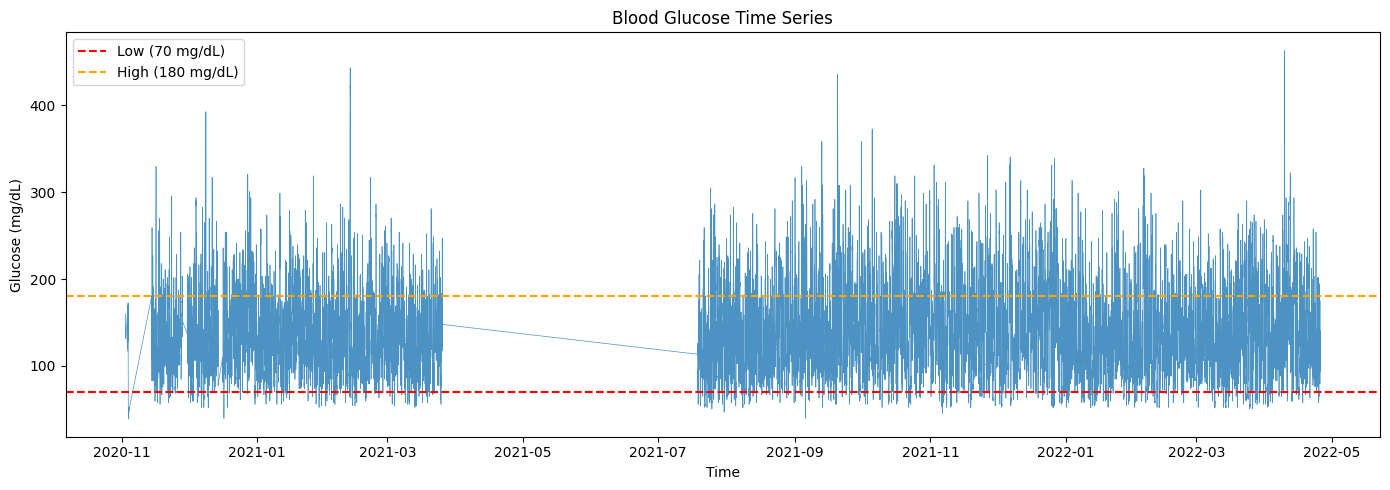

In [ ]:
# 5. Visualize the glucose time series
plt.figure(figsize=(14, 5))
plt.plot(glucose_data.index, glucose_data['Glucose_mgdL'], linewidth=0.5, alpha=0.8)
plt.axhline(y=70, color='r', linestyle='--', label='Low (70 mg/dL)')
plt.axhline(y=180, color='orange', linestyle='--', label='High (180 mg/dL)')
plt.xlabel('Time')
plt.ylabel('Glucose (mg/dL)')
plt.title('Blood Glucose Time Series')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Scaling & Sequence Creation

In [ ]:
# Normalize the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
glucose_scaled = scaler.fit_transform(glucose_data['Glucose_mgdL'].values.reshape(-1, 1))

print(f"Scaled data shape: {glucose_scaled.shape}")
print(f"Scaled range: [{glucose_scaled.min():.4f}, {glucose_scaled.max():.4f}]")

Scaled data shape: (38337, 1)
Scaled range: [0.0000, 1.0000]


In [ ]:
# Create sequences for time series prediction
# We'll use past 'sequence_length' readings to predict the next reading

def create_sequences(data, sequence_length):
    """
    Create input sequences and corresponding targets for time series prediction.

    Args:
        data: Scaled glucose data
        sequence_length: Number of past time steps to use for prediction

    Returns:
        X: Input sequences of shape (samples, sequence_length, features)
        y: Target values of shape (samples,)
    """
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# Define sequence length (e.g., 12 readings ≈ 3 hours with 15-min intervals)
SEQUENCE_LENGTH = 12

X, y = create_sequences(glucose_scaled, SEQUENCE_LENGTH)

print(f"Input shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")
print(f"Using {SEQUENCE_LENGTH} past readings to predict the next reading")

Input shape (X): (38325, 12, 1)
Target shape (y): (38325, 1)
Using 12 past readings to predict the next reading


## Train-Test Split

In [ ]:
# Split data into training and testing sets
# For time series, we keep temporal order (no shuffling)
TRAIN_SPLIT = 0.8

split_idx = int(len(X) * TRAIN_SPLIT)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Training samples: 30660
Testing samples: 7665

X_train shape: (30660, 12, 1)
X_test shape: (7665, 12, 1)
y_train shape: (30660, 1)
y_test shape: (7665, 1)


In [ ]:
# Helper function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    """
    Calculate and return evaluation metrics.
    """
    # Inverse transform to get actual glucose values
    y_true_actual = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
    y_pred_actual = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    mse = mean_squared_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    r2 = r2_score(y_true_actual, y_pred_actual)

    print(f"\n{'='*50}")
    print(f"{model_name} Results:")
    print(f"{'='*50}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f} mg/dL")
    print(f"MAE:  {mae:.4f} mg/dL")
    print(f"R²:   {r2:.4f}")

    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
            'y_true': y_true_actual, 'y_pred': y_pred_actual}

# Store results for comparison
results = []

## Model 1: LSTM (Long Short-Term Memory)

In [ ]:
# Build LSTM Model
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create and train LSTM model
lstm_model = build_lstm_model((SEQUENCE_LENGTH, 1))
lstm_model.summary()

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
print("\nTraining LSTM model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 0.0118 - mae: 0.0793 - val_loss: 0.0025 - val_mae: 0.0396
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0025 - mae: 0.0371 - val_loss: 8.4725e-04 - val_mae: 0.0211
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.0012 - mae: 0.0253 - val_loss: 6.0479e-04 - val_mae: 0.0176
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0010 - mae: 0.0228 - val_loss: 5.8302e-04 - val_mae: 0.0180
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 9.3123e-04 - mae: 0.0219 - val_loss: 5.6023e-04 - val_mae: 0.0172
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 8.7390e-04 - mae: 0.0213 - val_loss: 5.5046e-04 - val_mae: 0.0164
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 8.7664e-04 - mae: 0.0212 - val_loss: 5.7511e-04 - val_mae: 0.0167
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 8.5320e-04 - mae: 0.0208 - val_loss: 5.59

In [ ]:
# Evaluate LSTM
lstm_pred = lstm_model.predict(X_test, verbose=0)
lstm_results = evaluate_model(y_test, lstm_pred, "LSTM")
results.append(lstm_results)


LSTM Results:
MSE:  134.2951
RMSE: 11.5886 mg/dL
MAE:  7.3942 mg/dL
R²:   0.9467


## Model 2: GRU (Gated Recurrent Unit)

In [ ]:
# Build GRU Model
def build_gru_model(input_shape):
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create and train GRU model
gru_model = build_gru_model((SEQUENCE_LENGTH, 1))
gru_model.summary()

# Train the model
print("\nTraining GRU model...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU model...
Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.0115 - mae: 0.0733 - val_loss: 9.8134e-04 - val_mae: 0.0237
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0015 - mae: 0.0280 - val_loss: 6.0990e-04 - val_mae: 0.0186
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 9.9818e-04 - mae: 0.0227 - val_loss: 5.8198e-04 - val_mae: 0.0178
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 8.7662e-04 - mae: 0.0212 - val_loss: 5.5684e-04 - val_mae: 0.0169
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 8.5509e-04 - mae: 0.0208 - val_loss: 6.0224e-04 - val_mae: 0.0186
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 8.6054e-04 - mae: 0.0207 - val_loss: 5.7108e-04 - val_mae: 0.0177
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 8.3234e-04 - mae: 0.0205 - val_loss: 5.5197e-04 - val_mae: 0.0169
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 8.0566e-04 - mae: 0.0203 - val_l

In [ ]:
# Evaluate GRU
gru_pred = gru_model.predict(X_test, verbose=0)
gru_results = evaluate_model(y_test, gru_pred, "GRU")
results.append(gru_results)


GRU Results:
MSE:  130.2760
RMSE: 11.4139 mg/dL
MAE:  7.2755 mg/dL
R²:   0.9483


## Model 3: Simple RNN (Recurrent Neural Network)

In [ ]:
# Build Simple RNN Model
def build_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create and train RNN model
rnn_model = build_rnn_model((SEQUENCE_LENGTH, 1))
rnn_model.summary()

# Train the model
print("\nTraining Simple RNN model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 12, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)


Training Simple RNN model...
Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0134 - mae: 0.0797 - val_loss: 0.0014 - val_mae: 0.0280
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0021 - mae: 0.0338 - val_loss: 8.0681e-04 - val_mae: 0.0211
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0014 - mae: 0.0271 - val_loss: 6.5501e-04 - val_mae: 0.0190
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0011 - mae: 0.0245 - val_loss: 6.0523e-04 - val_mae: 0.0174
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0010 - mae: 0.0228 - val_loss: 5.7429e-04 - val_mae: 0.0175
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 9.1069e-04 - mae: 0.0218 - val_loss: 5.8802e-04 - val_mae: 0.0177
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.8557e-04 - mae: 0.0216 - val_loss: 6.4918e-04 - val_mae: 0.0186
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 8.8291e-04 - mae: 0.0212 - val_loss: 5.9213e-04 -

In [ ]:
# Evaluate RNN
rnn_pred = rnn_model.predict(X_test, verbose=0)
rnn_results = evaluate_model(y_test, rnn_pred, "Simple RNN")
results.append(rnn_results)


Simple RNN Results:
MSE:  136.9019
RMSE: 11.7005 mg/dL
MAE:  7.8153 mg/dL
R²:   0.9457


## Model 4: HMM (Hidden Markov Model)

In [ ]:
# Build HMM Model (Gaussian HMM for continuous observations)
# HMM is a generative model - we need to adapt it for prediction differently

# For HMM, we'll train on individual observations (not flattened sequences)
# and use it to model the underlying glucose dynamics

# Prepare data for HMM - use 2D format [n_samples, n_features]
train_data_hmm = y_train.reshape(-1, 1)  # Use target values for training

# Tune n_components - test different values
def train_and_evaluate_hmm(n_components, train_data, X_test, y_test):
    """Train HMM and evaluate using a proper prediction approach."""

    model = hmm.GaussianHMM(
        n_components=n_components,
        covariance_type='full',
        n_iter=200,
        random_state=42,
        tol=0.01
    )

    # Train on the sequence of glucose values
    model.fit(train_data)

    predictions = []

    for seq in X_test:
        # Get the sequence of past values
        seq_values = seq.reshape(-1, 1)

        # Decode to find the most likely state sequence
        _, state_sequence = model.decode(seq_values, algorithm='viterbi')

        # Get the last state
        last_state = state_sequence[-1]

        # Get transition probabilities from last state
        trans_probs = model.transmat_[last_state]

        # Predict next value as weighted average of state means by transition probability
        predicted_value = np.sum(trans_probs * model.means_.flatten())
        predictions.append(predicted_value)

    return model, np.array(predictions)

# Test different n_components values
print("Tuning HMM n_components...")
print("-" * 50)

best_rmse = float('inf')
best_n = None
best_model = None
best_pred = None

for n in [3, 5, 7, 10, 15, 20]:
    try:
        model, pred = train_and_evaluate_hmm(n, train_data_hmm, X_test, y_test)

        # Calculate RMSE
        pred_actual = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
        y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
        rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
        r2 = r2_score(y_test_actual, pred_actual)

        print(f"n_components={n:2d}: RMSE={rmse:.2f} mg/dL, R²={r2:.4f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_n = n
            best_model = model
            best_pred = pred
    except Exception as e:
        print(f"n_components={n:2d}: Failed - {str(e)[:50]}")

print("-" * 50)
print(f"Best n_components: {best_n}")

# Use the best model
hmm_model = best_model
hmm_pred = best_pred

# Evaluate HMM
hmm_results = evaluate_model(y_test, hmm_pred, "HMM")
results.append(hmm_results)

Tuning HMM n_components...
--------------------------------------------------
n_components= 3: RMSE=36.55 mg/dL, R²=0.4699
n_components= 5: RMSE=23.31 mg/dL, R²=0.7844
n_components= 7: RMSE=20.83 mg/dL, R²=0.8279
n_components=10: RMSE=18.79 mg/dL, R²=0.8599
n_components=15: RMSE=17.82 mg/dL, R²=0.8740
n_components=20: RMSE=16.74 mg/dL, R²=0.8888
--------------------------------------------------
Best n_components: 20

HMM Results:
MSE:  280.2970
RMSE: 16.7421 mg/dL
MAE:  12.1750 mg/dL
R²:   0.8888


## Model Comparison & Results

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': r['model'],
        'MSE': r['MSE'],
        'RMSE (mg/dL)': r['RMSE'],
        'MAE (mg/dL)': r['MAE'],
        'R² Score': r['R2']
    }
    for r in results
])

# Sort by RMSE (lower is better)
comparison_df = comparison_df.sort_values('RMSE (mg/dL)')
print("\n" + "="*70)
print("MODEL COMPARISON - Blood Glucose Prediction")
print("="*70)
print(comparison_df.to_string(index=False))
print("\n✓ Best model by RMSE:", comparison_df.iloc[0]['Model'])


MODEL COMPARISON - Blood Glucose Prediction
     Model         MSE  RMSE (mg/dL)  MAE (mg/dL)  R² Score
       GRU  130.276022     11.413852     7.275544  0.948308
      LSTM  134.295058     11.588574     7.394202  0.946713
Simple RNN  136.901872     11.700507     7.815294  0.945678
       HMM 3601.379112     60.011492    50.753348 -0.428998

✓ Best model by RMSE: GRU


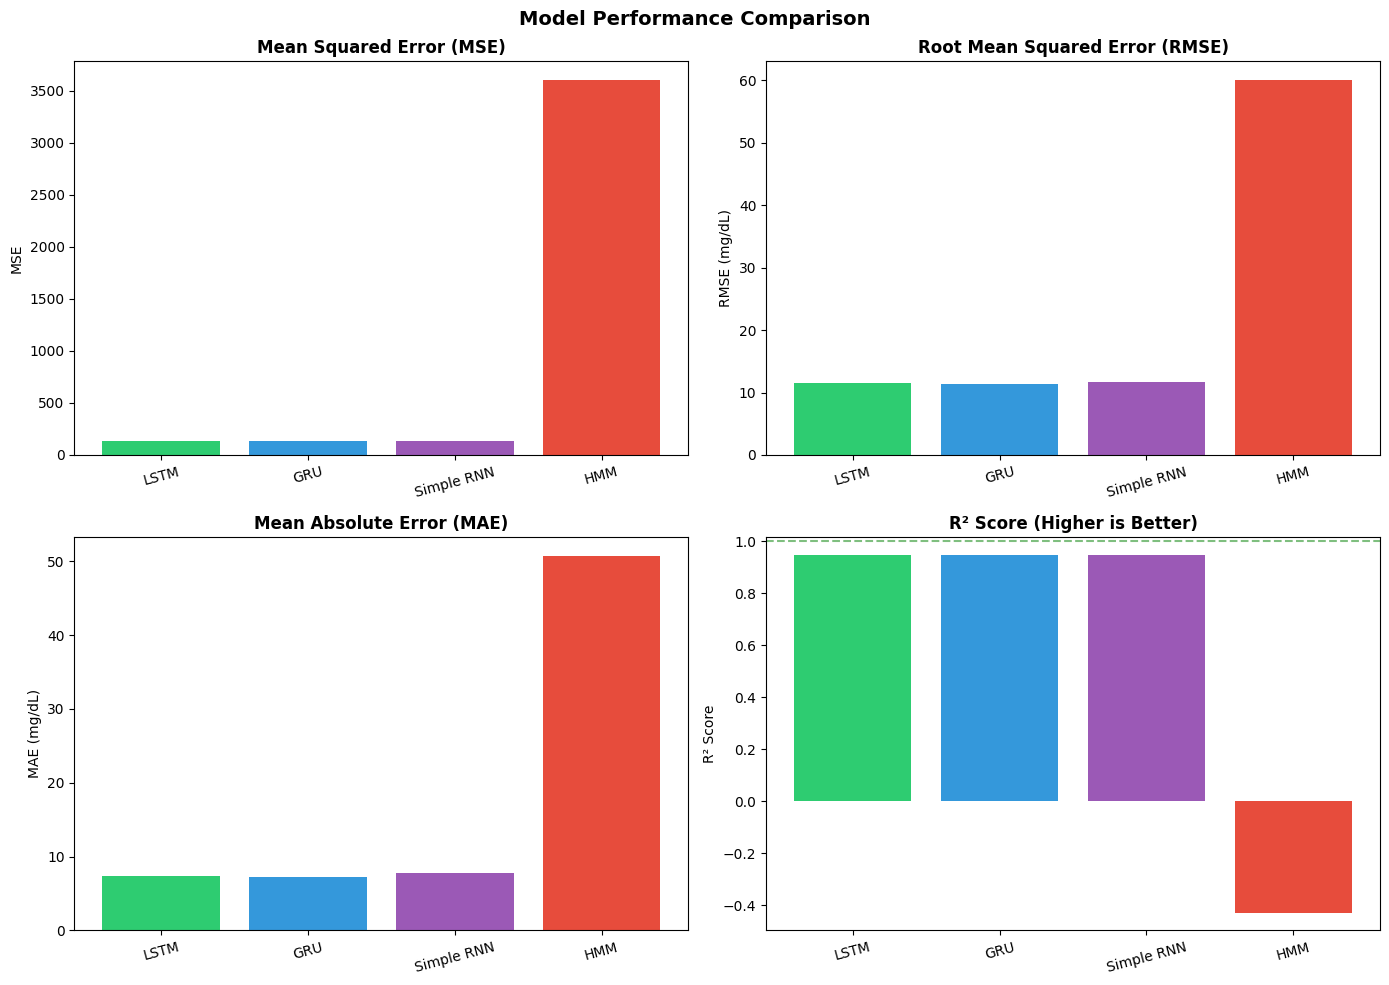

In [ ]:
# Visualize comparison - Bar plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = [r['model'] for r in results]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

# MSE
ax1 = axes[0, 0]
mse_vals = [r['MSE'] for r in results]
ax1.bar(models, mse_vals, color=colors)
ax1.set_title('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
ax1.set_ylabel('MSE')
ax1.tick_params(axis='x', rotation=15)

# RMSE
ax2 = axes[0, 1]
rmse_vals = [r['RMSE'] for r in results]
ax2.bar(models, rmse_vals, color=colors)
ax2.set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE (mg/dL)')
ax2.tick_params(axis='x', rotation=15)

# MAE
ax3 = axes[1, 0]
mae_vals = [r['MAE'] for r in results]
ax3.bar(models, mae_vals, color=colors)
ax3.set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax3.set_ylabel('MAE (mg/dL)')
ax3.tick_params(axis='x', rotation=15)

# R² Score
ax4 = axes[1, 1]
r2_vals = [r['R2'] for r in results]
ax4.bar(models, r2_vals, color=colors)
ax4.set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
ax4.set_ylabel('R² Score')
ax4.tick_params(axis='x', rotation=15)
ax4.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect Score')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

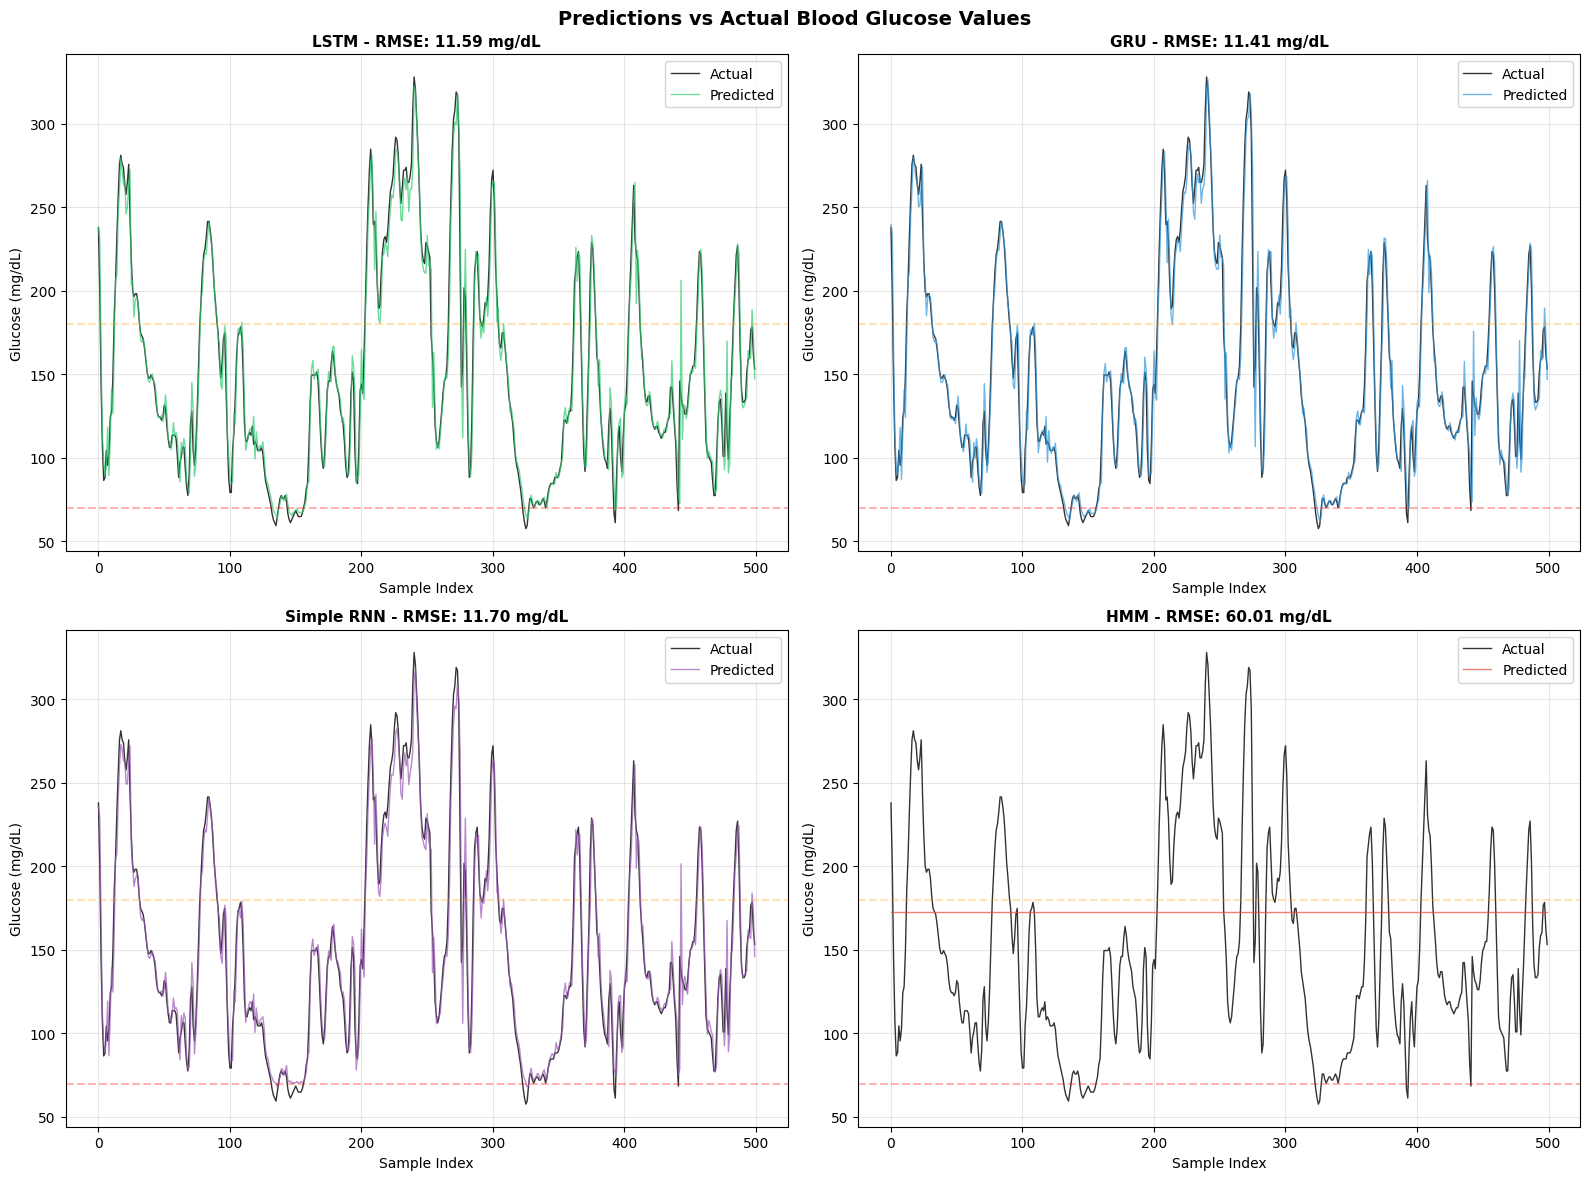

In [ ]:
# Visualize predictions vs actual values for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Get actual test values (use first result's y_true as reference)
y_actual = results[0]['y_true']
time_idx = range(len(y_actual))

for idx, (r, ax) in enumerate(zip(results, axes)):
    # Plot subset for clarity (first 500 points)
    plot_range = min(500, len(y_actual))

    ax.plot(time_idx[:plot_range], y_actual[:plot_range],
            label='Actual', color='black', linewidth=1, alpha=0.8)
    ax.plot(time_idx[:plot_range], r['y_pred'][:plot_range],
            label='Predicted', color=colors[idx], linewidth=1, alpha=0.7)

    ax.axhline(y=70, color='red', linestyle='--', alpha=0.3)
    ax.axhline(y=180, color='orange', linestyle='--', alpha=0.3)

    ax.set_title(f"{r['model']} - RMSE: {r['RMSE']:.2f} mg/dL", fontsize=11, fontweight='bold')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Glucose (mg/dL)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Predictions vs Actual Blood Glucose Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

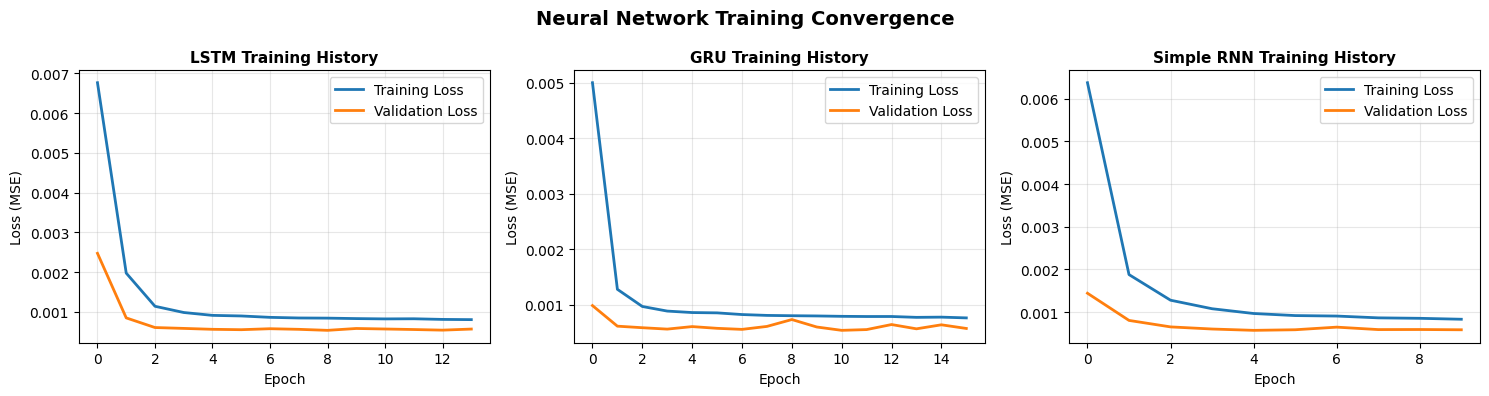

In [ ]:
# Training history comparison for neural network models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

histories = [
    ('LSTM', lstm_history),
    ('GRU', gru_history),
    ('Simple RNN', rnn_history)
]

for idx, (name, history) in enumerate(histories):
    ax = axes[idx]
    ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_title(f'{name} Training History', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Neural Network Training Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary & Conclusions

In [ ]:
# Final Summary
print("="*70)
print("BLOOD GLUCOSE PREDICTION - FINAL SUMMARY")
print("="*70)
print(f"\nDataset: {len(glucose_data)} glucose readings")
print(f"Sequence Length: {SEQUENCE_LENGTH} readings (~{SEQUENCE_LENGTH * 15} minutes)")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\n{'Model':<15} {'RMSE (mg/dL)':<15} {'MAE (mg/dL)':<15} {'R² Score':<10}")
print("-"*55)
for r in sorted(results, key=lambda x: x['RMSE']):
    print(f"{r['model']:<15} {r['RMSE']:<15.2f} {r['MAE']:<15.2f} {r['R2']:<10.4f}")

print("\n" + "="*70)
best_model = min(results, key=lambda x: x['RMSE'])
print(f"🏆 BEST MODEL: {best_model['model']}")
print(f"   RMSE: {best_model['RMSE']:.2f} mg/dL")
print(f"   MAE:  {best_model['MAE']:.2f} mg/dL")
print(f"   R²:   {best_model['R2']:.4f}")
print("="*70)

# Clinical interpretation
print("\n📋 Clinical Interpretation:")
print(f"   - Average prediction error: ±{best_model['MAE']:.1f} mg/dL")
if best_model['RMSE'] < 20:
    print("   - Excellent: Error is within clinically acceptable range for CGM devices")
elif best_model['RMSE'] < 30:
    print("   - Good: Error is acceptable for trend prediction")
else:
    print("   - Moderate: Consider adding more features (insulin, meals, activity)")

BLOOD GLUCOSE PREDICTION - FINAL SUMMARY

Dataset: 38337 glucose readings
Sequence Length: 12 readings (~180 minutes)
Training samples: 30660
Testing samples: 7665

Model           RMSE (mg/dL)    MAE (mg/dL)     R² Score  
-------------------------------------------------------
GRU             11.41           7.28            0.9483    
LSTM            11.59           7.39            0.9467    
Simple RNN      11.70           7.82            0.9457    
HMM             60.01           50.75           -0.4290   

🏆 BEST MODEL: GRU
   RMSE: 11.41 mg/dL
   MAE:  7.28 mg/dL
   R²:   0.9483

📋 Clinical Interpretation:
   - Average prediction error: ±7.3 mg/dL
   - Excellent: Error is within clinically acceptable range for CGM devices
